In [ ]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import re
import seaborn as sns

In [ ]:
# Read the datset
'''
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/parisrohan/credit-score-classification")
'''
df = pd.read_csv('credit-score-classification/train.csv')
df.head()
pd.set_option('display.max_columns',50) #to display all the columns

<ipython-input-8-c0537cf7dd09>:7: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('credit-score-classification/train.csv')


In [ ]:
df.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4,9.27,4.0,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8_,11.27,4.0,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6,11.27,4.0,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,4,5.42,2.0,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,7,1,7.42,2.0,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


In [ ]:
# Information about columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
# Main statistics of dataset
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


**Handling Missing Values**

In [ ]:
# Standardise missing data labels
df = df.replace(['_______','NAA','_','!@9#%8', '#F%$D@*&8','nan',''],np.nan)

# Clean dependent variable
df = df.dropna(subset=['Credit_Score'])

In [ ]:
# Remove unuseful columns and the columns which contains sensitive data
del df['ID'] # Identification
del df['Name'] # Name of client
del df['SSN'] # SSN (social security number of a person)

In [ ]:
# Replace '-' values in numerical columns
Numerical_columns = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Amount_invested_monthly', 'Outstanding_Debt' , 'Monthly_Balance']
def fix_nums(num):
    try :
        return float(num.replace("_",""))
    except :
        return np.nan
for col in Numerical_columns :
    df[col] = df[col].apply(fix_nums)
#df['Type_of_Loan'].value_counts().head(10)

In [ ]:
# Clean based on columns

# In the column 'Number of bank accounts'and 'Delay_from_due_date, it cannot be negative
df = df[df['Num_Bank_Accounts'] >= 0]
df = df[df['Delay_from_due_date'] >= 0]
df = df[df['Age'] >= 0]


#In the column 'Credit_History_Age', converting column format to months from years and months
def convert_to_months(age):
    try :
        years = int("".join(re.findall('[0-9]',''.join(age.split("and")[0]))))
        month = int("".join(re.findall('[0-9]',''.join(age.split("and")[1]))))
        return years*12 + month
    except :
        return np.nan
df['Credit_History_Age'] = df['Credit_History_Age'].apply(convert_to_months)
df['Credit_History_Age']

# In the column 'Payment_of_Min_Amount', replace typo "NM" with "No"
df['Payment_of_Min_Amount'].replace("NM","No",inplace=True)
df['Payment_of_Min_Amount'].value_counts()

Yes    51878
No     46629
Name: Payment_of_Min_Amount, dtype: int64

In [ ]:
# In the column 'Payment_Behaviour', split this column into 2 different columns i.e 'Spent_Behaviour', 'Payment_Behaviour'
print(df['Payment_Behaviour'].unique())

['High_spent_Small_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_value_payments' nan 'High_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Large_value_payments']


In [ ]:
df[['Spent_Behaviour', 'Payment_Behaviour']] = df['Payment_Behaviour'].str.extract(r'(High|Low)?_spent_(Small|Medium|Large)_value_payments').fillna({'Spent_Behaviour': np.nan, 'Payment_Behaviour': np.nan})
df.head()

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Spent_Behaviour
0,CUS_0xd40,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,NaN,809.98,26.822620,265.0,No,49.574949,80.415295,Small,312.494089,Good,High
3,CUS_0xd40,April,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,199.458074,Small,223.451310,Good,Low
4,CUS_0xd40,May,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,41.420153,Medium,341.489231,Good,High
5,CUS_0xd40,June,23.0,Scientist,19114.12,NaN,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4.0,9.27,4.0,Good,809.98,27.262259,270.0,No,49.574949,62.430172,NaN,340.479212,Good,NaN
6,CUS_0xd40,July,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8.0,11.27,4.0,Good,809.98,22.537593,271.0,No,49.574949,178.344067,Small,244.565317,Good,Low


In [ ]:
df['Type_of_Loan'].value_counts().head(9)

Not Specified              1378
Credit-Builder Loan        1258
Personal Loan              1252
Debt Consolidation Loan    1226
Student Loan               1213
Payday Loan                1176
Mortgage Loan              1159
Auto Loan                  1136
Home Equity Loan           1108
Name: Type_of_Loan, dtype: int64

In [ ]:
loan_types = ['Credit-Builder Loan', 'Personal Loan', 'Debt Consolidation Loan', 'Student Loan', 'Payday Loan', 'Mortgage Loan', 'Auto Loan', 'Home Equity Loan','Not Specified']

# Create binary columns for each loan type
for loan_type in loan_types:
    df[loan_type] = df['Type_of_Loan'].str.contains(loan_type, case=False).fillna(False).astype(int)

# Replace all binary columns with NaN if 'Type_of_Loan' is NaN
df[loan_types] = df[loan_types].where(df['Type_of_Loan'].notna(), np.nan)

df.drop(columns=['Type_of_Loan'],inplace=True)
df.head()


,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Spent_Behaviour,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Student Loan,Payday Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Not Specified
0,CUS_0xd40,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,NaN,809.98,26.822620,265.0,No,49.574949,80.415295,Small,312.494089,Good,High,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,CUS_0xd40,April,23.0,Scientist,19114.12,NaN,3,4,3,4.0,5,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,199.458074,Small,223.451310,Good,Low,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,CUS_0xd40,May,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,6,NaN,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,41.420153,Medium,341.489231,Good,High,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5,CUS_0xd40,June,23.0,Scientist,19114.12,NaN,3,4,3,4.0,8,4.0,9.27,4.0,Good,809.98,27.262259,270.0,No,49.574949,62.430172,NaN,340.479212,Good,NaN,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,CUS_0xd40,July,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,3,8.0,11.27,4.0,Good,809.98,22.537593,271.0,No,49.574949,178.344067,Small,244.565317,Good,Low,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
# Check the null values count in each column
df.isna().sum()

Customer_ID                     0
Month                           0
Age                             0
Occupation                   6946
Annual_Income                   0
Monthly_Inhand_Salary       14771
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Delay_from_due_date             0
Num_of_Delayed_Payment       6911
Changed_Credit_Limit         2066
Num_Credit_Inquiries         1927
Credit_Mix                  19903
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           8888
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4418
Payment_Behaviour            7482
Monthly_Balance              2833
Credit_Score                    0
Spent_Behaviour              7482
Credit-Builder Loan         11164
Personal Loan               11164
Debt Consolidation Loan     11164
Student Loan                11164
Payday Loan   

In [ ]:
missing_value_cols = [col for col in df.columns if df[col].isna().sum() > 0]
print(missing_value_cols)

['Occupation', 'Monthly_Inhand_Salary', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Credit_History_Age', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Spent_Behaviour', 'Credit-Builder Loan', 'Personal Loan', 'Debt Consolidation Loan', 'Student Loan', 'Payday Loan', 'Mortgage Loan', 'Auto Loan', 'Home Equity Loan', 'Not Specified']


In [ ]:
credit_mix_mapping = {'Good': 3, 'Standard': 2, 'Bad': 1}
df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_mapping)

month_mapping = {'January': 1,'February': 2,'March': 3,'April': 4,'May': 5,'June': 6,'July': 7,'August': 8,'September': 9,'October': 10,'November': 11,'December': 12}
df['Month'] = df['Month'].map(month_mapping)
df.head()

Payment_of_Min_Amount_mapping={'Yes':1,'No':0}
df['Payment_of_Min_Amount']=df['Payment_of_Min_Amount'].map(Payment_of_Min_Amount_mapping)

credit_score_mapping={'Poor':0, 'Standard':1, 'Good':2}
df['Credit_Score']=df['Credit_Score'].map(credit_score_mapping)


missing_value_col_types = df[missing_value_cols].dtypes
categorical_missing_value_cols = missing_value_col_types[missing_value_col_types == 'object'].index.tolist()

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

for col in categorical_missing_value_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))
    df[col].replace({-1: np.nan}, inplace=True)



In [ ]:
df.head(100)

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Spent_Behaviour,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Student Loan,Payday Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Not Specified
0,CUS_0xd40,1,23.0,12,19114.120,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,NaN,809.98,26.822620,265.0,0,49.574949,80.415295,2,312.494089,2,0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,CUS_0xd40,4,23.0,12,19114.120,NaN,3,4,3,4.0,5,4.0,6.27,4.0,3.0,809.98,31.377862,268.0,0,49.574949,199.458074,2,223.451310,2,1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,CUS_0xd40,5,23.0,12,19114.120,1824.843333,3,4,3,4.0,6,NaN,11.27,4.0,3.0,809.98,24.797347,269.0,0,49.574949,41.420153,1,341.489231,2,0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5,CUS_0xd40,6,23.0,12,19114.120,NaN,3,4,3,4.0,8,4.0,9.27,4.0,3.0,809.98,27.262259,270.0,0,49.574949,62.430172,3,340.479212,2,2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
6,CUS_0xd40,7,23.0,12,19114.120,1824.843333,3,4,3,4.0,3,8.0,11.27,4.0,3.0,809.98,22.537593,271.0,0,49.574949,178.344067,2,244.565317,2,1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,CUS_0x3e45,8,36.0,5,54392.160,4766.680000,6,4,14,3.0,10,8.0,5.54,7.0,2.0,179.22,32.878805,329.0,1,124.392082,495.117898,2,147.158020,1,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
104,CUS_0x6c66,1,39.0,8,8701.545,NaN,6,5,32,7.0,23,9.0,8.86,6.0,NaN,2602.69,24.523164,107.0,1,36.548197,13.066210,0,272.298468,0,1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
105,CUS_0x6c66,2,39.0,8,8701.545,519.128750,6,5,32,7.0,23,9.0,8.86,6.0,2.0,2602.69,39.902518,108.0,1,36.548197,34.715164,0,250.649514,0,1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
106,CUS_0x6c66,3,39.0,8,8701.545,519.128750,6,5,32,7.0,23,NaN,8.86,6.0,2.0,2602.69,36.475914,109.0,0,36.548197,45.650976,0,239.713702,0,1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 98507 entries, 0 to 99999
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               98507 non-null  object 
 1   Month                     98507 non-null  int64  
 2   Age                       98507 non-null  float64
 3   Occupation                98507 non-null  int64  
 4   Annual_Income             98507 non-null  float64
 5   Monthly_Inhand_Salary     83736 non-null  float64
 6   Num_Bank_Accounts         98507 non-null  int64  
 7   Num_Credit_Card           98507 non-null  int64  
 8   Interest_Rate             98507 non-null  int64  
 9   Num_of_Loan               98507 non-null  float64
 10  Delay_from_due_date       98507 non-null  int64  
 11  Num_of_Delayed_Payment    91596 non-null  float64
 12  Changed_Credit_Limit      96441 non-null  float64
 13  Num_Credit_Inquiries      96580 non-null  float64
 14  Credit

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3)
df[missing_value_cols] = imputer.fit_transform(df[missing_value_cols])
print(df.isnull().sum())


Customer_ID                 0
Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Spent_Behaviour             0
Credit-Builder Loan         0
Personal Loan               0
Debt Consolidation Loan     0
Student Loan                0
Payday Loan                 0
Mortgage Loan               0
Auto Loan                   0
Home Equity Loan            0
Not Specif

In [ ]:
# Remove duplicates
df = df.drop_duplicates()


In [ ]:
df.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Spent_Behaviour,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Student Loan,Payday Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Not Specified
count,98507.000000,98507.000000,98507.000000,9.850700e+04,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,9.850700e+04,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000
mean,4.500107,116.182941,7.523942,1.768401e+05,4404.812898,17.196382,22.457602,72.379181,3.012882,21.205011,31.221727,10.419103,27.766037,2.081757,1430.962626,32.282031,219.973542,0.526643,1402.568378,649.772388,1.279899,-9.616914e+24,0.884567,0.649903,0.347623,0.335820,0.338886,0.329726,0.366492,0.349349,0.349941,0.343729,0.341231
std,2.291027,687.067398,4.640229,1.433852e+06,3186.000706,117.820260,128.957182,466.003347,62.482854,14.789449,219.693072,6.761952,191.993771,0.707654,1156.771566,5.116097,97.481735,0.499292,8303.094047,2016.505752,0.914117,5.579592e+25,0.673589,0.615988,0.459454,0.458736,0.458203,0.459222,0.460443,0.457730,0.455642,0.459594,0.460505
min,1.000000,14.000000,0.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,-100.000000,0.000000,-3.000000,-6.490000,0.000000,1.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-3.333333e+26,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,25.000000,4.000000,1.943348e+04,1719.660000,4.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.390000,3.000000,2.000000,568.720000,28.051671,146.000000,0.000000,30.447777,76.339128,1.000000,2.644331e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,33.000000,7.000000,3.751641e+04,3374.450000,6.000000,6.000000,14.000000,3.000000,18.000000,14.000000,9.440000,6.000000,2.000000,1169.620000,32.303559,219.000000,1.000000,69.318349,140.527454,1.000000,3.315328e+02,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,42.000000,12.000000,7.262912e+04,6325.727500,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.880000,9.000000,3.000000,1958.280000,36.493936,296.000000,1.000000,161.340704,284.436914,2.000000,4.626209e+02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,8.000000,8698.000000,15.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,1496.000000,67.000000,4397.000000,36.970000,2597.000000,3.000000,4998.070000,50.000000,404.000000,1.000000,82331.000000,10000.000000,3.000000,1.602041e+03,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Detect outliers Using IQR

numerical_columns = ['Age','Num_Bank_Accounts','Num_Credit_Card','Num_of_Loan','Num_of_Delayed_Payment','Num_Credit_Inquiries','Interest_Rate']
outlier_list=[]
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_threshold) | (df[col] > upper_threshold)]
    if(outliers.shape[0]>0):
      outlier_list.append(col)


#Handling outliers

for col in outlier_list:
    df[col] = df[col].apply(lambda x: df[col].median() if x < lower_threshold or x > upper_threshold else x)
df.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Spent_Behaviour,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Student Loan,Payday Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Not Specified
count,98507.000000,98507.000000,98507.000000,9.850700e+04,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,9.850700e+04,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000
mean,4.500107,29.111911,7.523942,1.768401e+05,4404.812898,5.399626,5.562600,14.570528,3.523323,21.205011,13.346019,10.419103,5.795876,2.081757,1430.962626,32.282031,219.973542,0.526643,1402.568378,649.772388,1.279899,-9.616914e+24,0.884567,0.649903,0.347623,0.335820,0.338886,0.329726,0.366492,0.349349,0.349941,0.343729,0.341231
std,2.291027,6.160675,4.640229,1.433852e+06,3186.000706,2.599726,2.097715,8.649571,2.411399,14.789449,6.133084,6.761952,3.821180,0.707654,1156.771566,5.116097,97.481735,0.499292,8303.094047,2016.505752,0.914117,5.579592e+25,0.673589,0.615988,0.459454,0.458736,0.458203,0.459222,0.460443,0.457730,0.455642,0.459594,0.460505
min,1.000000,14.000000,0.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,-3.000000,-6.490000,0.000000,1.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-3.333333e+26,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,25.000000,4.000000,1.943348e+04,1719.660000,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.390000,3.000000,2.000000,568.720000,28.051671,146.000000,0.000000,30.447777,76.339128,1.000000,2.644331e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,33.000000,7.000000,3.751641e+04,3374.450000,6.000000,6.000000,14.000000,3.000000,18.000000,14.000000,9.440000,6.000000,2.000000,1169.620000,32.303559,219.000000,1.000000,69.318349,140.527454,1.000000,3.315328e+02,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,33.000000,12.000000,7.262912e+04,6325.727500,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.880000,8.000000,3.000000,1958.280000,36.493936,296.000000,1.000000,161.340704,284.436914,2.000000,4.626209e+02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,8.000000,38.000000,15.000000,2.419806e+07,15204.633333,38.000000,38.000000,34.000000,33.000000,67.000000,28.000000,36.970000,37.000000,3.000000,4998.070000,50.000000,404.000000,1.000000,82331.000000,10000.000000,3.000000,1.602041e+03,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


array([[<Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Occupation'}>,
        <Axes: title={'center': 'Annual_Income'}>,
        <Axes: title={'center': 'Monthly_Inhand_Salary'}>,
        <Axes: title={'center': 'Num_Bank_Accounts'}>],
       [<Axes: title={'center': 'Num_Credit_Card'}>,
        <Axes: title={'center': 'Interest_Rate'}>,
        <Axes: title={'center': 'Num_of_Loan'}>,
        <Axes: title={'center': 'Delay_from_due_date'}>,
        <Axes: title={'center': 'Num_of_Delayed_Payment'}>,
        <Axes: title={'center': 'Changed_Credit_Limit'}>],
       [<Axes: title={'center': 'Num_Credit_Inquiries'}>,
        <Axes: title={'center': 'Credit_Mix'}>,
        <Axes: title={'center': 'Outstanding_Debt'}>,
        <Axes: title={'center': 'Credit_Utilization_Ratio'}>,
        <Axes: title={'center': 'Credit_History_Age'}>,
        <Axes: title={'center': 'Payment_of_Min_Amount'}>],
       [<Axes: title={'center': 'To

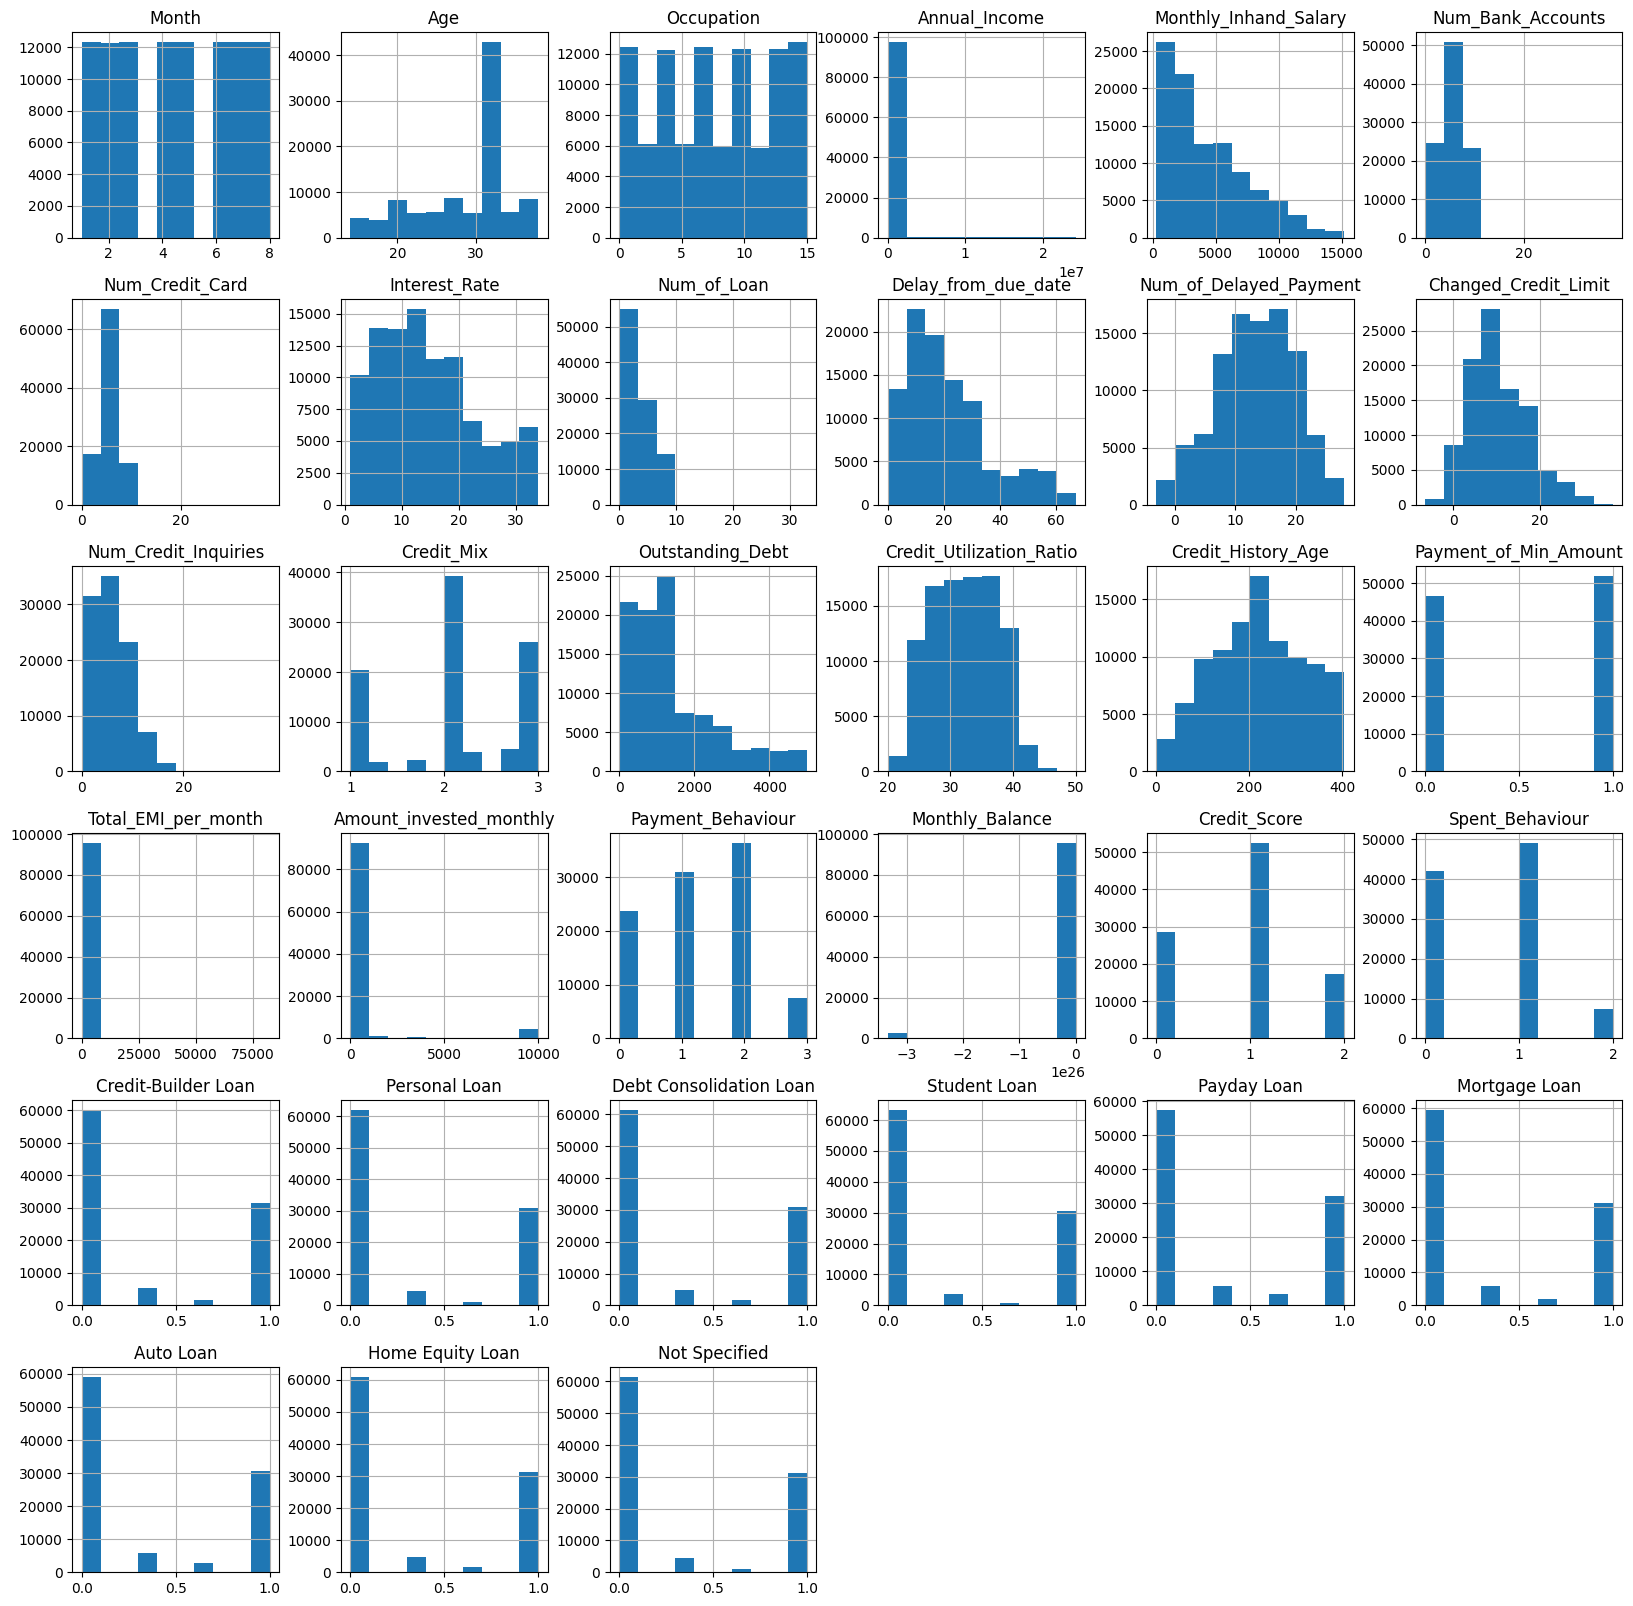

In [ ]:
df.hist(figsize=(20, 20))


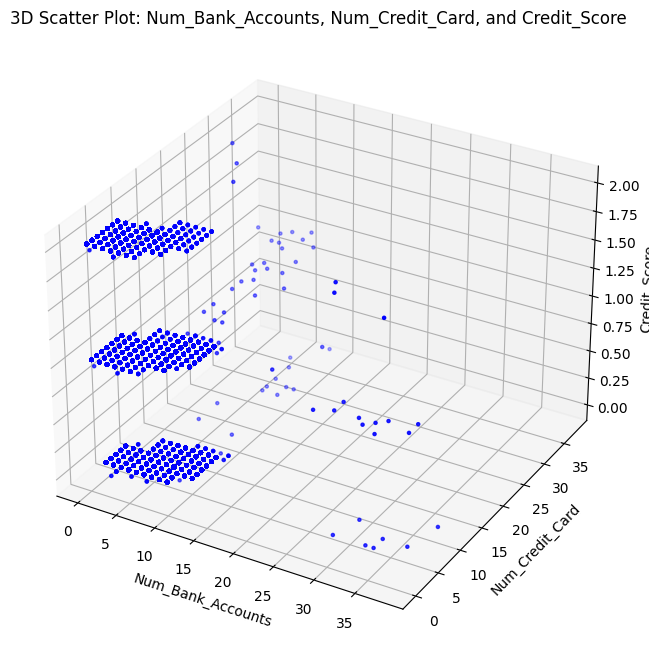

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['Num_Bank_Accounts']
y = df['Num_Credit_Card']
z = df['Credit_Score']

ax.scatter(x, y, z, c='b', marker='.')
ax.set_xlabel('Num_Bank_Accounts')
ax.set_ylabel('Num_Credit_Card')
ax.set_zlabel('Credit_Score')

plt.title('3D Scatter Plot: Num_Bank_Accounts, Num_Credit_Card, and Credit_Score')
plt.show()


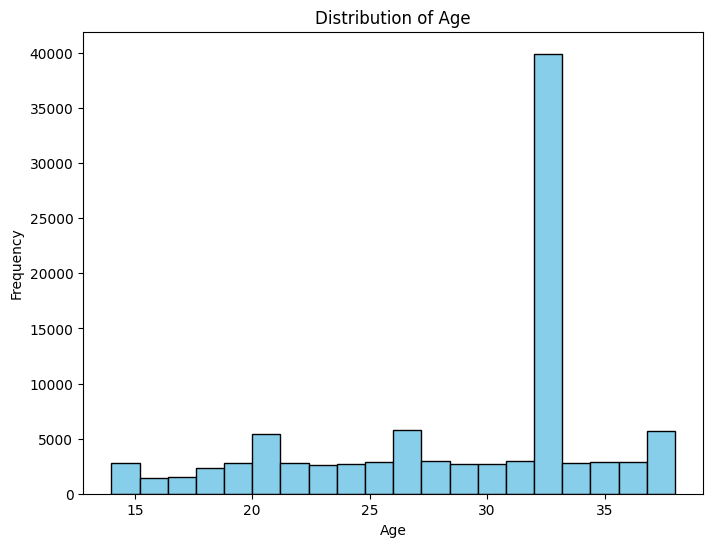

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


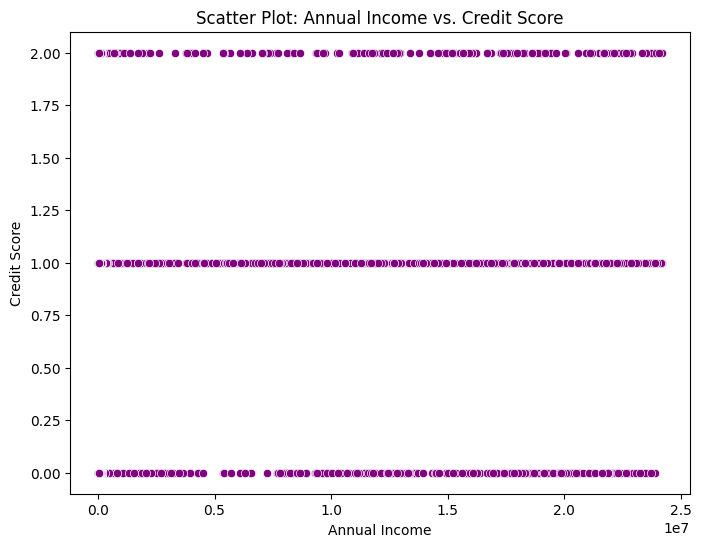

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Credit_Score', color='purple')
plt.title('Scatter Plot: Annual Income vs. Credit Score')
plt.xlabel('Annual Income')
plt.ylabel('Credit Score')
plt.show()


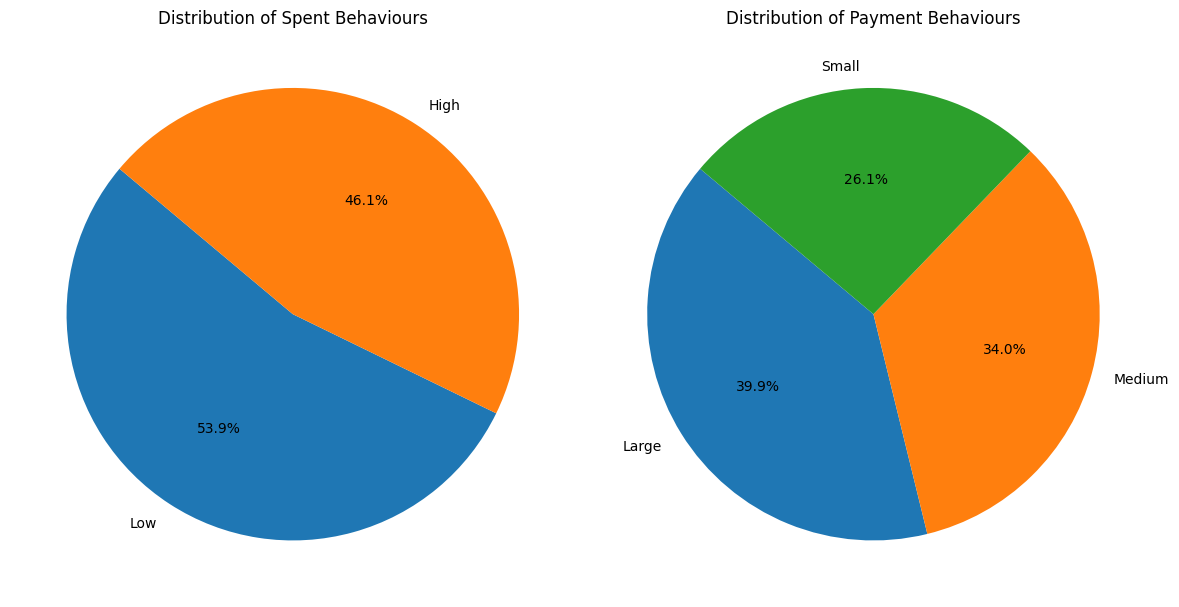

In [ ]:
import matplotlib.pyplot as plt

spent_behavior_labels = {0: 'High', 1: 'Low'}
df['Spent_Behaviour_Labels'] = df['Spent_Behaviour'].map(spent_behavior_labels)

payment_behavior_labels = {0: 'Small', 1: 'Medium', 2: 'Large'}
df['Payment_Behaviour_Labels'] = df['Payment_Behaviour'].map(payment_behavior_labels)

spent_behavior_counts = df['Spent_Behaviour_Labels'].value_counts()
payment_behavior_counts = df['Payment_Behaviour_Labels'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(spent_behavior_counts, labels=spent_behavior_counts.index, autopct='%1.1f%%', startangle=140)
ax1.set_title('Distribution of Spent Behaviours')

ax2.pie(payment_behavior_counts, labels=payment_behavior_counts.index, autopct='%1.1f%%', startangle=140)
ax2.set_title('Distribution of Payment Behaviours')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

columns_to_normalize = ['Annual_Income','Monthly_Inhand_Salary','Amount_invested_monthly','Monthly_Balance']

df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()
df.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Spent_Behaviour,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Student Loan,Payday Loan,Mortgage Loan,Auto Loan,Home Equity Loan,Not Specified
count,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000,98507.000000
mean,4.500107,29.111911,7.523942,0.007021,0.275228,5.399626,5.562600,14.570528,3.523323,21.205011,13.346019,10.419103,5.795876,2.081757,1430.962626,32.282031,219.973542,0.526643,1402.568378,0.064977,1.279899,0.971149,0.884567,0.649903,0.347623,0.335820,0.338886,0.329726,0.366492,0.349349,0.349941,0.343729,0.341231
std,2.291027,6.160675,4.640229,0.059272,0.213811,2.599726,2.097715,8.649571,2.411399,14.789449,6.133084,6.761952,3.821180,0.707654,1156.771566,5.116097,97.481735,0.499292,8303.094047,0.201651,0.914117,0.167388,0.673589,0.615988,0.459454,0.458736,0.458203,0.459222,0.460443,0.457730,0.455642,0.459594,0.460505
min,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.000000,-6.490000,0.000000,1.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,25.000000,4.000000,0.000514,0.095028,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.390000,3.000000,2.000000,568.720000,28.051671,146.000000,0.000000,30.447777,0.007634,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,33.000000,7.000000,0.001261,0.206081,6.000000,6.000000,14.000000,3.000000,18.000000,14.000000,9.440000,6.000000,2.000000,1169.620000,32.303559,219.000000,1.000000,69.318349,0.014053,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,33.000000,12.000000,0.002713,0.404140,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.880000,8.000000,3.000000,1958.280000,36.493936,296.000000,1.000000,161.340704,0.028444,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,8.000000,38.000000,15.000000,1.000000,1.000000,38.000000,38.000000,34.000000,33.000000,67.000000,28.000000,36.970000,37.000000,3.000000,4998.070000,50.000000,404.000000,1.000000,82331.000000,1.000000,3.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<ipython-input-30-357ef9b4eff1>:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


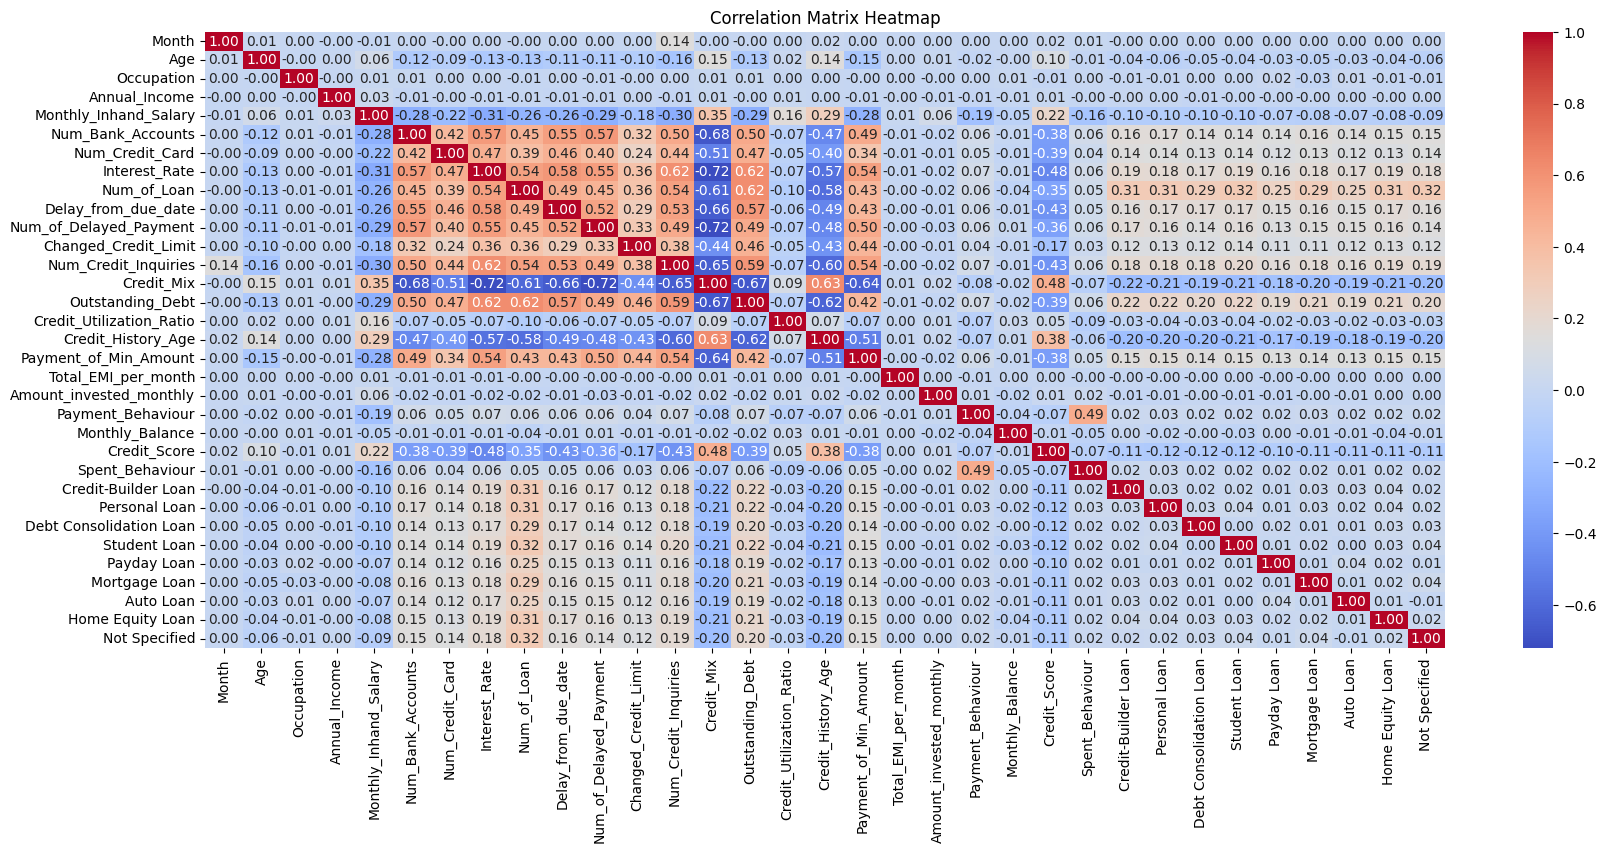

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(20, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()
